# Quantum Circuit Simulator: Sphinx examples

Executable examples from the Quickstart and Visualization chapters. Run this notebook from the repository root.

## Public interface

The public package exports `SimulationConfig`, `SimulationResult`, `simulate`, and `plot_simulation_result`.

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from quantum_circuit_simulator import (
    SimulationConfig,
    SimulationResult,
    plot_simulation_result,
    simulate,
)

## Simulation ohne Messung



In [10]:
circuit = QuantumCircuit(1)
circuit.h(0)

result = simulate(circuit)
print('Statevector:', result.statevector)
print('Counts:', result.counts)

assert np.allclose(np.abs(result.statevector) ** 2, [0.5, 0.5])
assert result.counts is None

Statevector: [0.70710678+0.j 0.70710678+0.j]
Counts: None


## Bell state Messung



In [3]:
bell_circuit = QuantumCircuit(2)
bell_circuit.h(0)
bell_circuit.cx(0, 1)
bell_circuit.measure_all()

bell_result = simulate(bell_circuit, SimulationConfig(shots=2_000, seed=7))
print('Statevector:', bell_result.statevector)
print('Counts:', bell_result.counts)
print('Counted shots:', sum(bell_result.counts.values()))

Statevector: [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]
Counts: {'11': 987, '00': 1013}
Counted shots: 2000


## Visualisierung



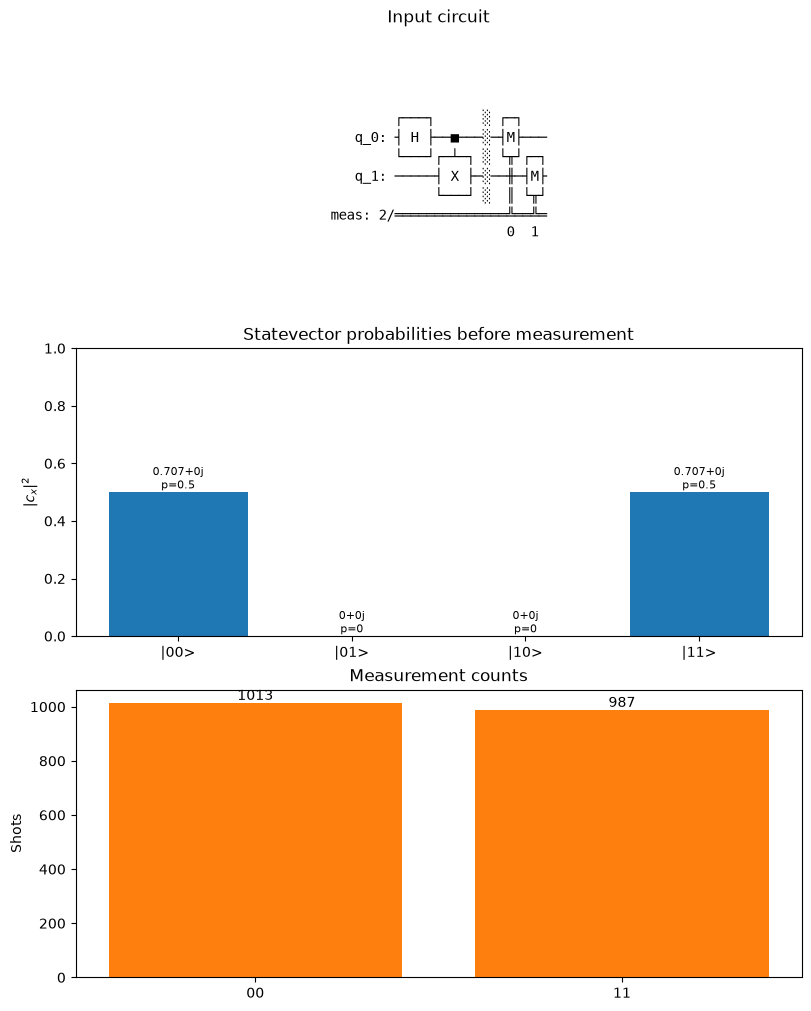

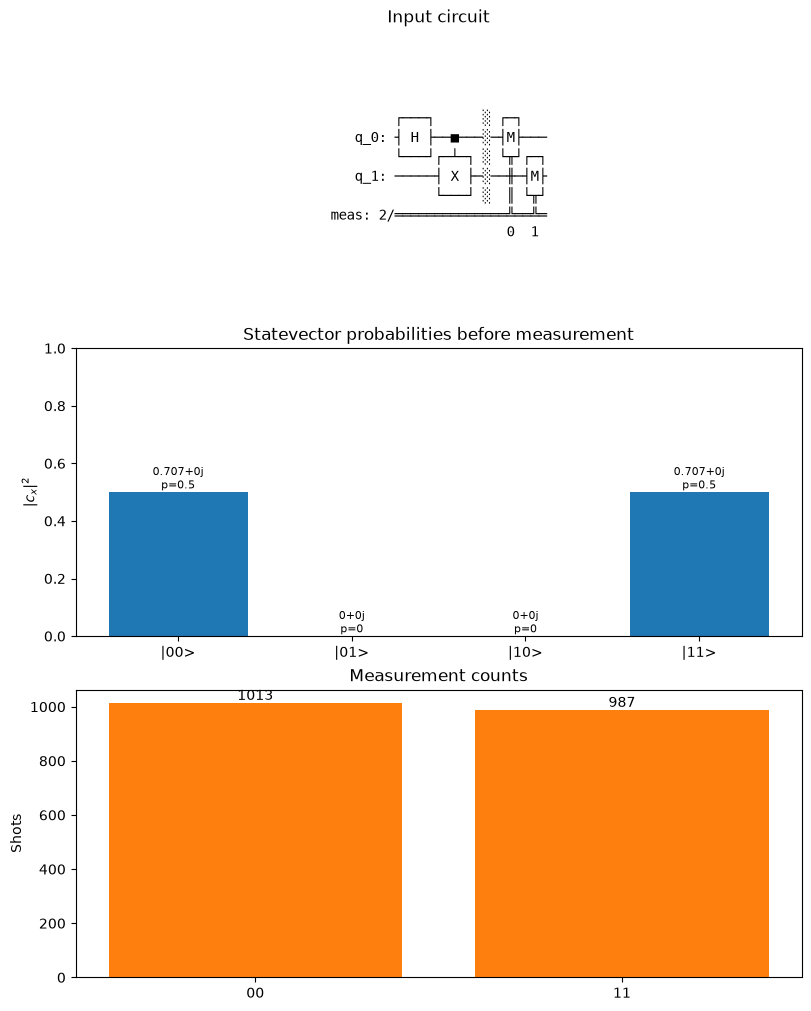

In [6]:
figure = plot_simulation_result(bell_circuit, bell_result, show=False)
figure